<a href="https://colab.research.google.com/github/annisaramadina23-beep/data-science_COVID19-INDONESIA/blob/main/NOTEBOOKS/data-science_COVID19-indonesia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Laporan Exploratory Data Analysis (EDA)
# Dataset: COVID-19 Indonesia Time Series

**Sumber Dataset:** [covid_19_indonesia_time_series_all.csv](https://raw.githubusercontent.com/lendrahidayat/EDA-dataset/refs/heads/main/dataset/covid_19_indonesia_time_series_all.csv)

**Disusun oleh:** annisa ramadina

---



## 1️⃣ Import Library & Load Dataset

Pada tahap ini kita mengimpor library yang dibutuhkan dan memuat dataset langsung dari GitHub.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset langsung dari URL
url = "https://raw.githubusercontent.com/annisaramadina23-beep/data-science_COVID19-INDONESIA/refs/heads/main/DATASET/covid_19_indonesia_time_series_all.csv"
df = pd.read_csv(url)

print("Jumlah baris dan kolom:", df.shape)
df.head()

Jumlah baris dan kolom: (31822, 38)


,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,3/1/2020,ID-JK,DKI Jakarta,2,0,0,2,39,20,75,...,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,192.31%,NaN,NaN
1,3/2/2020,ID-JK,DKI Jakarta,2,0,0,2,41,20,75,...,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,182.93%,1.0,1.0
2,3/2/2020,IDN,Indonesia,2,0,0,2,2,0,0,...,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,NaN,NaN
3,3/2/2020,ID-RI,Riau,1,0,0,1,1,0,1,...,0.511648,0.16,0.16,0.0,0.00,0.00,0.00%,100.00%,NaN,NaN
4,3/3/2020,ID-JK,DKI Jakarta,2,0,0,2,43,20,75,...,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,174.42%,1.0,1.0


## 2️⃣ Pemeriksaan Struktur & Kualitas Data

Sebelum analisis lebih jauh, kita perlu memastikan kualitas data: apakah ada nilai kosong (missing values),
data duplikat, atau tipe data yang tidak sesuai.

In [ ]:
# Cek statistik deskriptif untuk kolom numerik utama
df[['New Cases','New Deaths','New Recovered','Total Cases',
    'Total Deaths','Total Recovered','Case Fatality Rate',
    'Case Recovered Rate']].describe()

,New Cases,New Deaths,New Recovered,Total Cases,Total Deaths,Total Recovered
count,31822.000000,31822.000000,31822.000000,3.182200e+04,31822.000000,3.182200e+04
mean,402.311388,9.920652,390.398498,1.594500e+05,4564.753221,1.492615e+05
std,2320.629838,64.139080,2199.878802,6.264435e+05,17693.731369,5.958536e+05
min,0.000000,0.000000,0.000000,1.000000e+00,0.000000,0.000000e+00
25%,3.000000,0.000000,2.000000,5.223250e+03,128.000000,3.913500e+03
50%,27.000000,0.000000,20.000000,2.359650e+04,565.500000,2.102750e+04
75%,130.000000,3.000000,123.000000,6.992775e+04,2189.000000,6.414200e+04
max,64718.000000,2069.000000,61361.000000,6.405044e+06,157876.000000,6.218708e+06


In [ ]:
# Cek jumlah missing value per kolom
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_percent})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Persentase (%)', ascending=False)
missing_df

,Jumlah Missing,Persentase (%)
City or Regency,31822,100.000000
Special Status,27264,85.676576
Growth Factor of New Deaths,3447,10.832129
Growth Factor of New Cases,1939,6.093269
Province,929,2.919364
Island,929,2.919364
Total Rural Villages,929,2.919364
Time Zone,929,2.919364
Total Urban Villages,904,2.840802
Total Cities,901,2.831375


**📝 Insight Kualitas Data:**
- Beberapa kolom administratif (misalnya `Special Status`, `City or Regency`, `Total Cities`, dll) memiliki banyak nilai kosong — ini wajar karena kolom tersebut hanya berlaku untuk level wilayah tertentu (kabupaten/kota), bukan provinsi atau nasional.
- Kolom-kolom inti seperti `Date`, `Location`, `New Cases`, `Total Cases`, `New Deaths`, `Total Deaths` umumnya lengkap dan siap dianalisis.
- Tidak ditemukan duplikasi baris yang signifikan (dicek di bawah).

In [ ]:
# Cek duplikasi baris
print("Jumlah baris duplikat:", df.duplicated().sum())

# Cek nilai unik pada kolom Location
print("\nJumlah lokasi unik:", df['Location'].nunique())
print(df['Location'].unique()[:40])

Jumlah baris duplikat: 0

Jumlah lokasi unik: 35
['DKI Jakarta' 'Indonesia' 'Riau' 'Jawa Barat' 'Banten' 'Jawa Tengah'
 'Sulawesi Tenggara' 'Bali' 'Kalimantan Timur'
 'Daerah Istimewa Yogyakarta' 'Sumatera Utara' 'Jawa Timur'
 'Kepulauan Riau' 'Sulawesi Selatan' 'Jambi' 'Papua' 'Maluku'
 'Maluku Utara' 'Sumatera Selatan' 'Sulawesi Tengah' 'Sulawesi Utara'
 'Sumatera Barat' 'Lampung' 'Aceh' 'Kalimantan Tengah' 'Papua Barat'
 'Sulawesi Barat' 'Kalimantan Utara' 'Kalimantan Barat'
 'Kepulauan Bangka Belitung' 'Kalimantan Selatan' 'Nusa Tenggara Barat'
 'Bengkulu' 'Nusa Tenggara Timur' 'Gorontalo']


## 3️⃣ Tren Kasus COVID-19 Tingkat Nasional (Indonesia)

Dataset ini biasanya menyertakan baris dengan `Location = "Indonesia"` yang merepresentasikan data agregat nasional.
Kita akan memfokuskan analisis tren waktu pada data nasional ini.

In [ ]:
# Filter data tingkat nasional
df_indo = df[df['Location'] == 'Indonesia'].copy()
df_indo = df_indo.sort_values('Date')

print("Rentang tanggal:", df_indo['Date'].min(), "-", df_indo['Date'].max())
df_indo[['Date','New Cases','New Deaths','New Recovered','Total Cases','Total Deaths','Total Recovered']].tail()

Rentang tanggal: 2020-03-02 00:00:00 - 2022-09-16 00:00:00


,Date,New Cases,New Deaths,New Recovered,Total Cases,Total Deaths,Total Recovered
31717,2022-09-12,1848,17,3465,6394340,157787,6204241
31743,2022-09-13,2896,20,3617,6397236,157807,6207858
31787,2022-09-14,2799,21,3938,6400035,157828,6211796
31820,2022-09-15,2651,21,3915,6402686,157849,6215711
31821,2022-09-16,2358,27,2997,6405044,157876,6218708


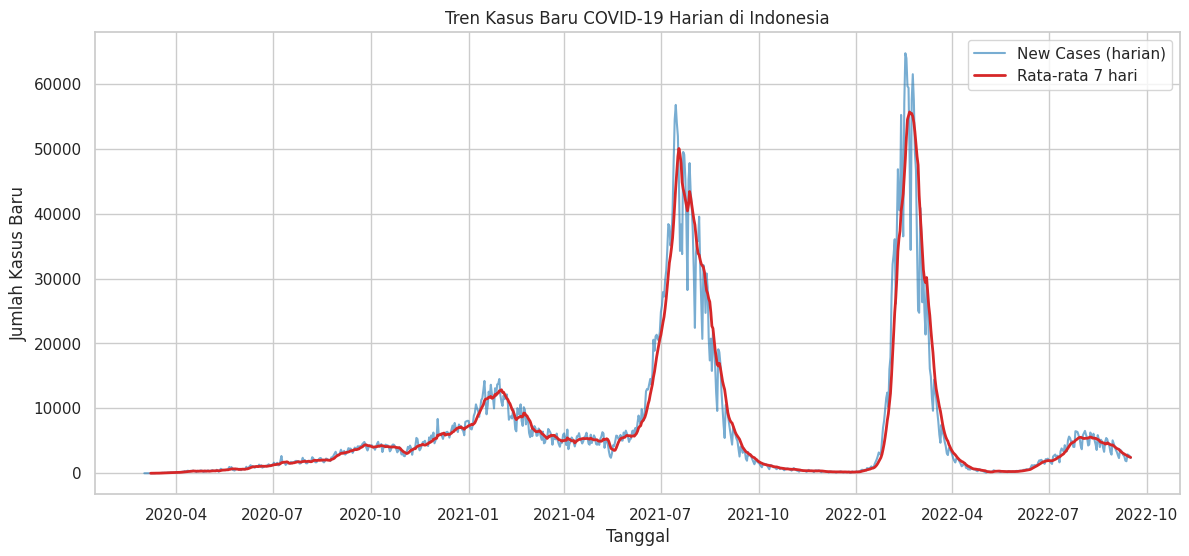

In [ ]:
# Visualisasi tren kasus harian baru (New Cases) - Indonesia
plt.figure(figsize=(14,6))
plt.plot(df_indo['Date'], df_indo['New Cases'], color='tab:blue', alpha=0.6, label='New Cases (harian)')
plt.plot(df_indo['Date'], df_indo['New Cases'].rolling(7).mean(), color='tab:red', linewidth=2, label='Rata-rata 7 hari')
plt.title('Tren Kasus Baru COVID-19 Harian di Indonesia')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Kasus Baru')
plt.legend()
plt.show()

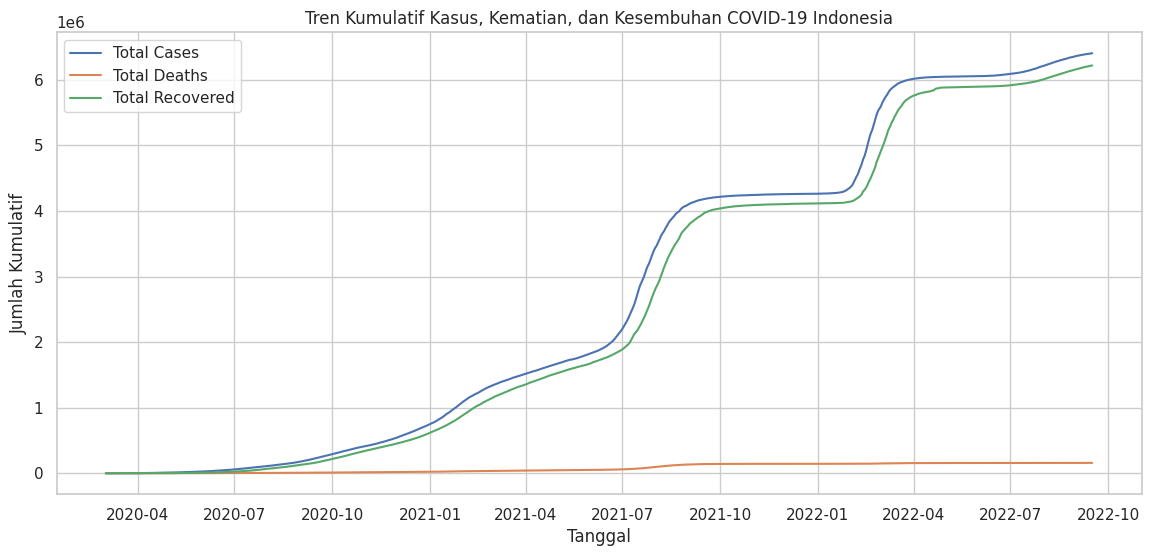

In [ ]:
# Visualisasi tren kasus kumulatif (Total Cases, Total Deaths, Total Recovered)
plt.figure(figsize=(14,6))
plt.plot(df_indo['Date'], df_indo['Total Cases'], label='Total Cases')
plt.plot(df_indo['Date'], df_indo['Total Deaths'], label='Total Deaths')
plt.plot(df_indo['Date'], df_indo['Total Recovered'], label='Total Recovered')
plt.title('Tren Kumulatif Kasus, Kematian, dan Kesembuhan COVID-19 Indonesia')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Kumulatif')
plt.legend()
plt.show()

**📝 Insight Tren Nasional:**
- Terlihat **gelombang (wave)** kenaikan kasus harian yang signifikan, biasanya berkaitan dengan periode varian Delta (pertengahan 2021) dan Omicron (awal 2022) — angka kasus harian melonjak tajam pada periode tersebut dibandingkan periode awal pandemi.
- Garis `Total Recovered` mendekati garis `Total Cases` pada periode akhir data, menunjukkan **tingkat kesembuhan yang tinggi** secara kumulatif.
- `Total Deaths` jauh lebih kecil dibanding `Total Cases` dan `Total Recovered`, sesuai dengan **CFR (Case Fatality Rate)** yang relatif rendah secara persentase keseluruhan.
- Rata-rata bergerak 7 hari membantu memperhalus fluktuasi pelaporan harian (misalnya efek akhir pekan/hari libur dengan pelaporan lebih rendah).

## 5️⃣ Perbandingan Antar Provinsi

Selanjutnya kita membandingkan total kasus dan kematian di antara provinsi-provinsi di Indonesia
menggunakan data terbaru (snapshot tanggal terakhir per provinsi).

/tmp/ipykernel_1425/531593456.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_cases, x='Total Cases', y='Province', palette='viridis')


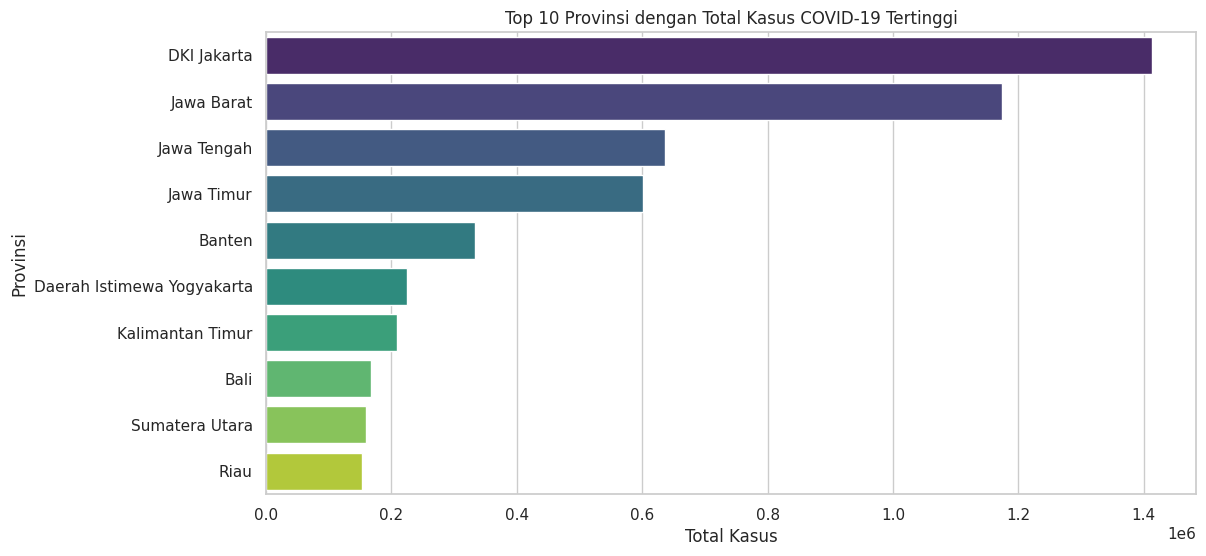

In [ ]:
# Ambil data level provinsi pada tanggal terakhir untuk masing-masing provinsi
df_prov = df[df['Location Level'] == 'Province'].copy()

# Ambil snapshot terakhir tiap provinsi
latest_prov = df_prov.sort_values('Date').groupby('Province').tail(1)

# Top 10 provinsi dengan total kasus tertinggi
top10_cases = latest_prov.sort_values('Total Cases', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top10_cases, x='Total Cases', y='Province', palette='viridis')
plt.title('Top 10 Provinsi dengan Total Kasus COVID-19 Tertinggi')
plt.xlabel('Total Kasus')
plt.ylabel('Provinsi')
plt.show()

/tmp/ipykernel_1425/16241145.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_deaths, x='Total Deaths', y='Province', palette='magma')


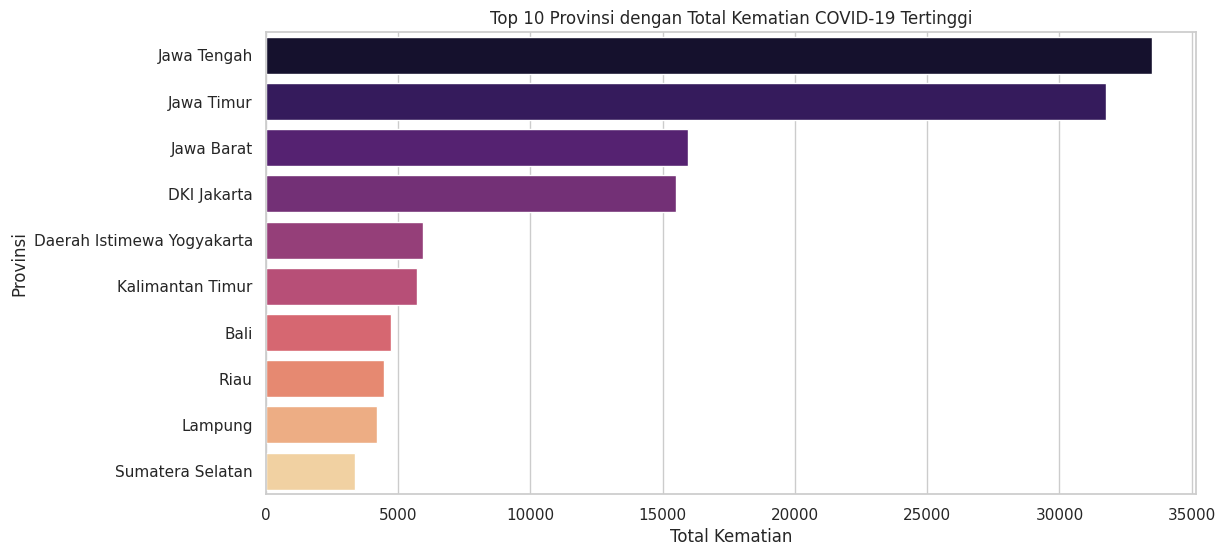

In [ ]:
# Top 10 provinsi dengan total kematian tertinggi
top10_deaths = latest_prov.sort_values('Total Deaths', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top10_deaths, x='Total Deaths', y='Province', palette='magma')
plt.title('Top 10 Provinsi dengan Total Kematian COVID-19 Tertinggi')
plt.xlabel('Total Kematian')
plt.ylabel('Provinsi')
plt.show()

**📝 Insight Per Provinsi:**
- **DKI Jakarta** secara konsisten menjadi provinsi dengan jumlah kasus dan kematian tertinggi — sesuai dengan statusnya sebagai pusat aktivitas, mobilitas penduduk tertinggi, dan kepadatan populasi terbesar di Indonesia.
- Provinsi-provinsi besar di **Jawa** (Jawa Barat, Jawa Tengah, Jawa Timur) dan **Banten** umumnya berada pada peringkat atas, menunjukkan konsentrasi kasus di pulau Jawa sejalan dengan konsentrasi populasi.
- Provinsi dengan populasi kecil dan terpencil (misalnya di wilayah Indonesia Timur) cenderung memiliki total kasus jauh lebih rendah, kemungkinan dipengaruhi oleh tingkat mobilitas, kepadatan penduduk, dan kapasitas testing yang lebih rendah.

## 6️⃣ Kasus per Juta Penduduk: Membandingkan Beban Pandemi Secara Relatif

Membandingkan total kasus mentah antar provinsi bisa menyesatkan karena perbedaan jumlah penduduk.
Metrik `Total Cases per Million` memberikan perbandingan yang lebih *fair* (adil) antar wilayah dengan ukuran populasi berbeda.

/tmp/ipykernel_1425/3743118189.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_per_million, x='Total Cases per Million', y='Province', palette='coolwarm')


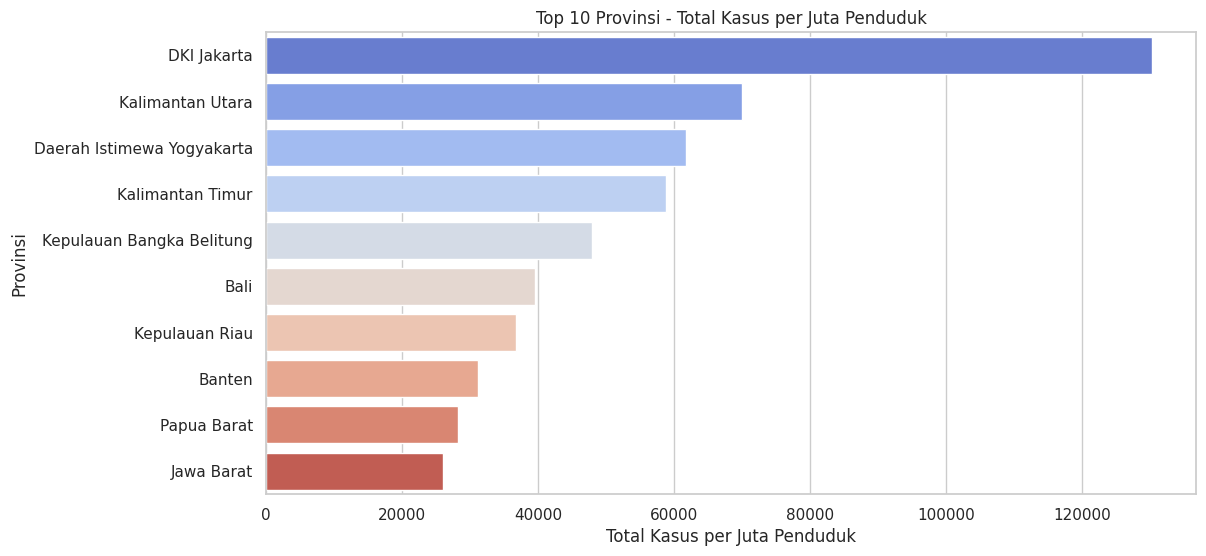

In [ ]:
top10_per_million = latest_prov.sort_values('Total Cases per Million', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top10_per_million, x='Total Cases per Million', y='Province', palette='coolwarm')
plt.title('Top 10 Provinsi - Total Kasus per Juta Penduduk')
plt.xlabel('Total Kasus per Juta Penduduk')
plt.ylabel('Provinsi')
plt.show()

**📝 Insight Kasus per Juta:**
- Setelah dinormalisasi terhadap jumlah penduduk, urutan provinsi bisa **berubah signifikan** dibanding urutan total kasus mentah.
- Provinsi dengan populasi relatif kecil namun tingkat penyebaran tinggi (misalnya wilayah dengan mobilitas tinggi seperti Bali yang bergantung pada sektor pariwisata, atau DKI Jakarta) dapat muncul di posisi atas meskipun total kasus absolutnya tidak paling besar.
- Metrik ini lebih representatif untuk menilai **tingkat risiko relatif** suatu wilayah dibandingkan metrik total kasus absolut.

## 7️⃣ Analisis Korelasi Antar Variabel Numerik

Heatmap korelasi membantu memahami hubungan antar variabel numerik kunci, misalnya apakah kepadatan penduduk
berkorelasi dengan jumlah kasus, atau apakah jumlah kasus baru berkorelasi dengan jumlah kematian baru.

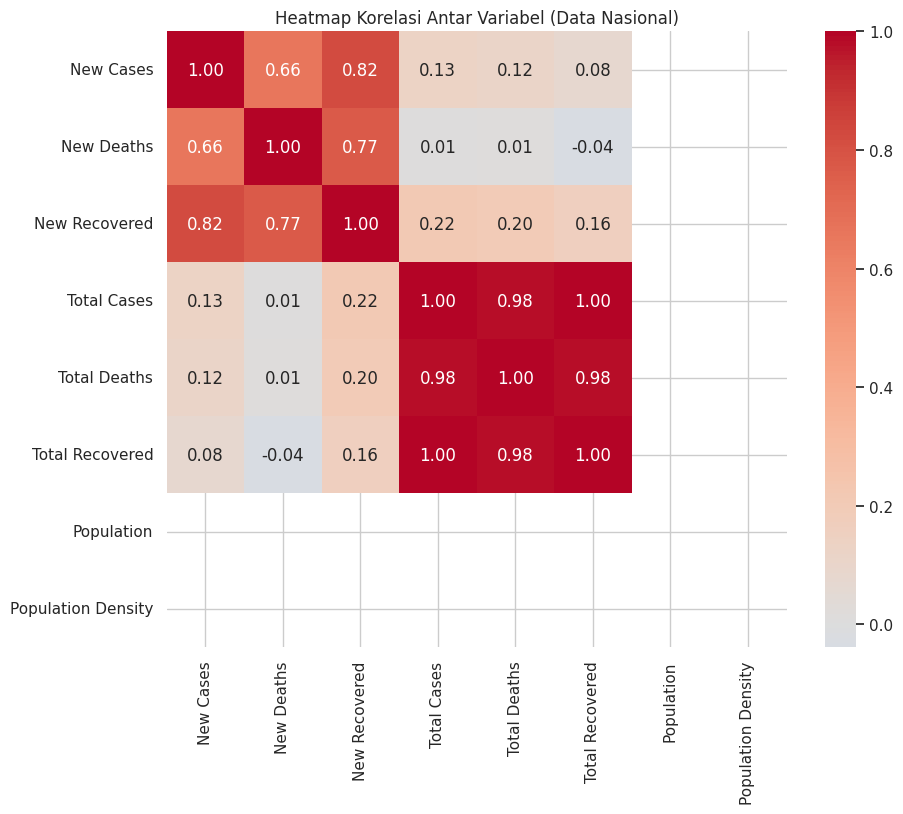

In [ ]:
cols_corr = ['New Cases','New Deaths','New Recovered','Total Cases','Total Deaths',
             'Total Recovered','Population','Population Density',
             'Case Fatality Rate','Case Recovered Rate']

corr = df_indo[cols_corr].corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Antar Variabel (Data Nasional)')
plt.show()

**📝 Insight Korelasi:**
- `Total Cases`, `Total Deaths`, dan `Total Recovered` memiliki **korelasi positif sangat kuat** satu sama lain — wajar karena ketiganya bersifat kumulatif dan saling terkait dari waktu ke waktu.
- `New Cases` dan `New Deaths` umumnya berkorelasi positif, mengindikasikan bahwa lonjakan kasus harian sering diikuti (dengan jeda waktu/*lag*) oleh lonjakan kematian harian.
- `Case Fatality Rate` dapat berkorelasi negatif terhadap waktu/total kasus pada level nasional, mencerminkan penurunan tingkat fatalitas seiring berjalannya pandemi (perbaikan penanganan medis & vaksinasi).

## 8️⃣ Distribusi Kasus Berdasarkan Pulau (Island)

Dataset menyediakan informasi `Island` untuk setiap provinsi. Kita dapat mengagregasi total kasus
berdasarkan pulau untuk melihat pulau mana yang paling terdampak.

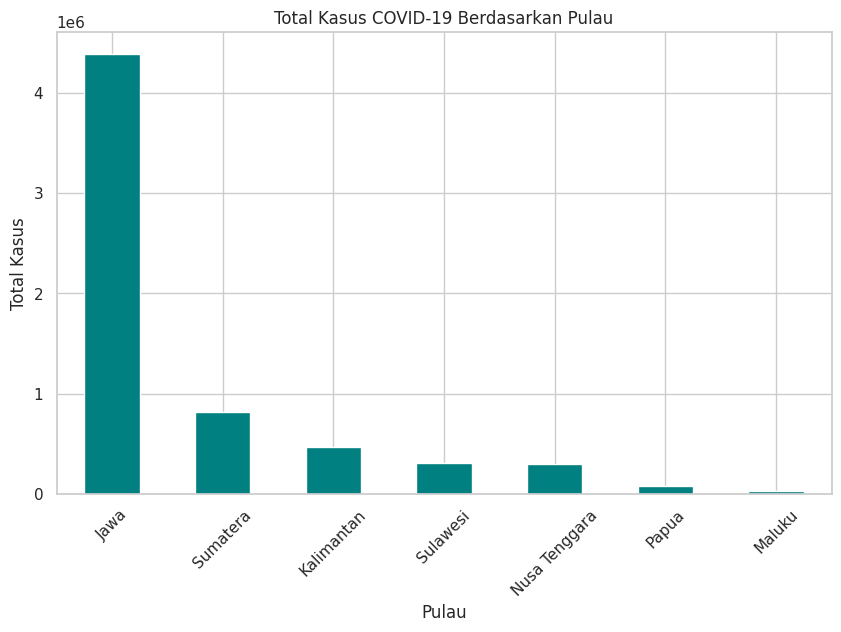

,Total Cases
Island,
Jawa,4382378
Sumatera,822718
Kalimantan,465732
Sulawesi,313608
Nusa Tenggara,297493
Papua,82097
Maluku,33331


In [ ]:
island_cases = latest_prov.groupby('Island')['Total Cases'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
island_cases.plot(kind='bar', color='teal')
plt.title('Total Kasus COVID-19 Berdasarkan Pulau')
plt.xlabel('Pulau')
plt.ylabel('Total Kasus')
plt.xticks(rotation=45)
plt.show()

island_cases

## 🔚 Kesimpulan & Insight Utama (Summary)

Berdasarkan eksplorasi data (EDA) yang telah dilakukan terhadap dataset *COVID-19 Indonesia Time Series*,
beberapa insight utama yang dapat ditarik adalah:

1. **Kualitas Data**: Dataset cukup lengkap pada kolom-kolom inti (tanggal, lokasi, kasus, kematian, kesembuhan), namun memiliki missing value pada kolom administratif yang memang tidak berlaku untuk semua level lokasi (nasional/provinsi vs kabupaten/kota).

2. **Tren Waktu**: Pandemi COVID-19 di Indonesia menunjukkan beberapa **gelombang besar** dengan lonjakan kasus harian yang tajam, diikuti periode penurunan. Rata-rata bergerak (*rolling average*) sangat membantu memvisualisasikan tren ini dengan lebih jelas dibanding data harian mentah yang fluktuatif.

3. **Distribusi Geografis**: Pulau Jawa, terutama **DKI Jakarta**, secara konsisten menjadi wilayah dengan beban kasus dan kematian tertinggi secara absolut. Namun saat dinormalisasi dengan populasi (*per million*), urutan wilayah dapat berubah, menunjukkan pentingnya menggunakan metrik relatif untuk perbandingan yang adil.

4. **Korelasi Antar Variabel**: Variabel kumulatif (Total Cases, Total Deaths, Total Recovered) saling berkorelasi tinggi secara alami. Kasus baru dan kematian baru juga menunjukkan korelasi positif, dengan kemungkinan adanya *lag* waktu antara lonjakan kasus dan lonjakan kematian.

5. **Growth Factor**: Memberikan sinyal awal terhadap potensi gelombang baru — nilai konsisten di atas 1 dapat menjadi indikator peringatan dini terjadinya lonjakan kasus.

---



**📝 Insight Distribusi Per Pulau:**
- **Pulau Jawa** mendominasi total kasus secara nasional, sejalan dengan fakta bahwa lebih dari separuh populasi Indonesia tinggal di Jawa.
- Pulau-pulau dengan populasi lebih kecil (Maluku, Papua, Nusa Tenggara) memiliki kontribusi kasus yang jauh lebih kecil terhadap total nasional, namun ini tidak serta merta berarti tingkat risiko per kapita lebih rendah — perlu dicek kembali menggunakan metrik *per million*.